In [11]:
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
prices = pd.read_csv(ROOT / "data" / "clean_data.csv")
signals = pd.read_csv(ROOT / "data" / "signals_strategy_3.csv")

In [12]:
df = prices.merge(
    signals,
    on="Date",
    how="inner"
)
print(df.head())

         Date        Close         High          Low         Open  Volume  \
0  2010-02-02  4830.100098  4951.149902  4814.100098  4907.850098       0   
1  2010-02-03  4931.850098  4949.149902  4831.000000  4831.000000       0   
2  2010-02-04  4845.350098  4931.299805  4832.350098  4931.299805       0   
3  2010-02-05  4718.649902  4827.000000  4692.350098  4819.649902       0   
4  2010-02-08  4760.399902  4799.049805  4675.399902  4755.350098       0   

   Target_Position  Trade_Size  
0         0.049854    0.049854  
1         0.019778   -0.030076  
2         0.026631    0.006853  
3         0.000890   -0.025741  
4         0.000013   -0.000877  


In [13]:
df["Return"] = df["Close"].pct_change()

print(df[["Date","Close","Return"]].head(10))

         Date        Close    Return
0  2010-02-02  4830.100098       NaN
1  2010-02-03  4931.850098  0.021066
2  2010-02-04  4845.350098 -0.017539
3  2010-02-05  4718.649902 -0.026149
4  2010-02-08  4760.399902  0.008848
5  2010-02-09  4792.649902  0.006775
6  2010-02-10  4757.200195 -0.007397
7  2010-02-11  4826.850098  0.014641
8  2010-02-15  4801.950195 -0.005159
9  2010-02-16  4855.750000  0.011204


In [14]:
df["Strategy_Return"] = (
    df["Target_Position"].shift(1)
    * df["Return"]
)

df["Strategy_Return"] = (
    df["Strategy_Return"]
    .fillna(0)
)

print(df[["Date","Return","Target_Position","Strategy_Return"]].head(10))

         Date    Return  Target_Position  Strategy_Return
0  2010-02-02       NaN     4.985393e-02     0.000000e+00
1  2010-02-03  0.021066     1.977812e-02     1.050214e-03
2  2010-02-04 -0.017539     2.663102e-02    -3.468895e-04
3  2010-02-05 -0.026149     8.902561e-04    -6.963699e-04
4  2010-02-08  0.008848     1.322611e-05     7.876870e-06
5  2010-02-09  0.006775     4.594105e-07     8.960212e-08
6  2010-02-10 -0.007397     3.809579e-07    -3.398114e-09
7  2010-02-11  0.014641     8.280469e-08     5.577583e-09
8  2010-02-15 -0.005159     1.095809e-07    -4.271582e-10
9  2010-02-16  0.011204     5.786113e-08     1.227716e-09


In [15]:
df["Equity"] = (
    1 + df["Strategy_Return"]
).cumprod()

print(
    df[["Date","Equity"]]
    .head(10)
)

         Date    Equity
0  2010-02-02  1.000000
1  2010-02-03  1.001050
2  2010-02-04  1.000703
3  2010-02-05  1.000006
4  2010-02-08  1.000014
5  2010-02-09  1.000014
6  2010-02-10  1.000014
7  2010-02-11  1.000014
8  2010-02-15  1.000014
9  2010-02-16  1.000014


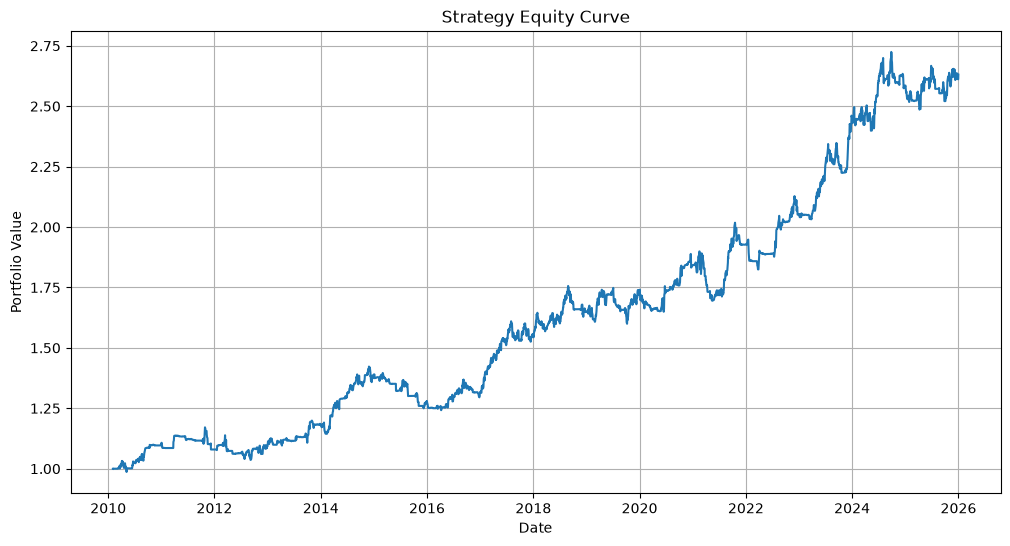

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["Date"] = pd.to_datetime(df["Date"])

plt.plot(
    df["Date"],
    df["Equity"]
)

plt.title("Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()

In [17]:
years = (
    (df["Date"].iloc[-1] - df["Date"].iloc[0])
    .days
    / 365.25
)

final_equity = df["Equity"].iloc[-1]

cagr = (
    final_equity ** (1 / years)
    - 1
)

print(f"CAGR: {cagr:.2%}")

CAGR: 6.27%


In [18]:
sharpe = (
    df["Strategy_Return"].mean()
    /
    df["Strategy_Return"].std()
) * (252 ** 0.5)

print(f"Sharpe Ratio: {sharpe:.2f}")

Sharpe Ratio: 0.86


In [19]:
df["Rolling_Max"] = (
    df["Equity"]
    .cummax()
)

df["Drawdown"] = (
    df["Equity"]
    /
    df["Rolling_Max"]
    - 1
)

max_drawdown = (
    df["Drawdown"]
    .min()
)

print(
    f"Max Drawdown: {max_drawdown:.2%}"
)

Max Drawdown: -12.69%


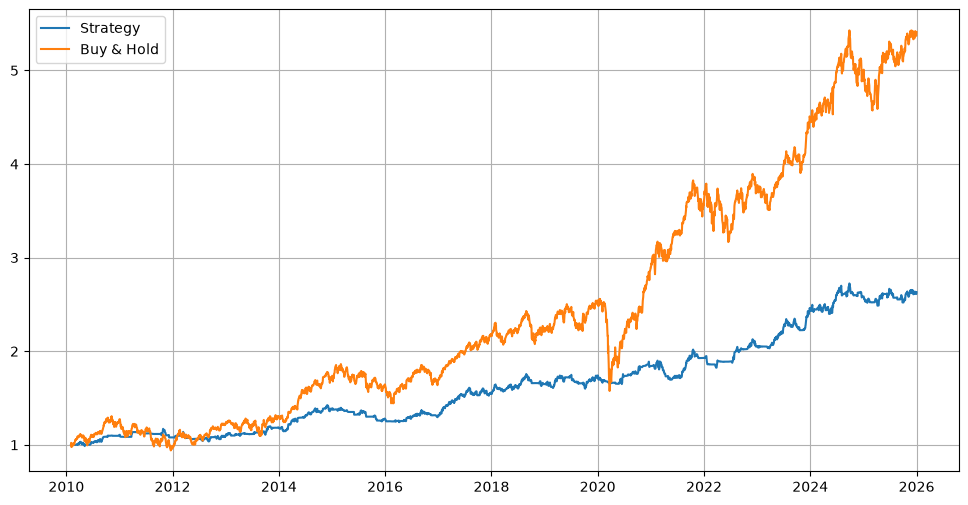

In [20]:
df["Market_Equity"] = (
    1 + df["Return"].fillna(0)
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Equity"], label="Strategy")
plt.plot(df["Date"], df["Market_Equity"], label="Buy & Hold")

plt.legend()
plt.grid(True)
plt.show()